### config & imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from scipy.stats import linregress
from scipy.signal import find_peaks
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_squared_error
import pickle
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv("od_readings_filtered-Demo_experiment-all_units-20260507114552.csv")
df = df.sort_values("hours_since_experiment_created")

FILES = {
    "Session 1": {
        "gr":  "growth_rates-Demo_experiment-all_units-20260424144615.csv",
        "dos": "dosing_events-Demo_experiment-all_units-20260424144615.csv",
    },
    "Session 2": {
        "gr":  "growth_rates-Demo_experiment-all_units-20260424214253.csv",
        "dos": "dosing_events-Demo_experiment-all_units-20260424214253.csv",
    },
}


df = pd.read_csv("od_readings_filtered-Demo_experiment-all_units-20260507114552.csv")
df = df.sort_values("hours_since_experiment_created")


### Implied growth rate and sine wave dosing (nutrient media)

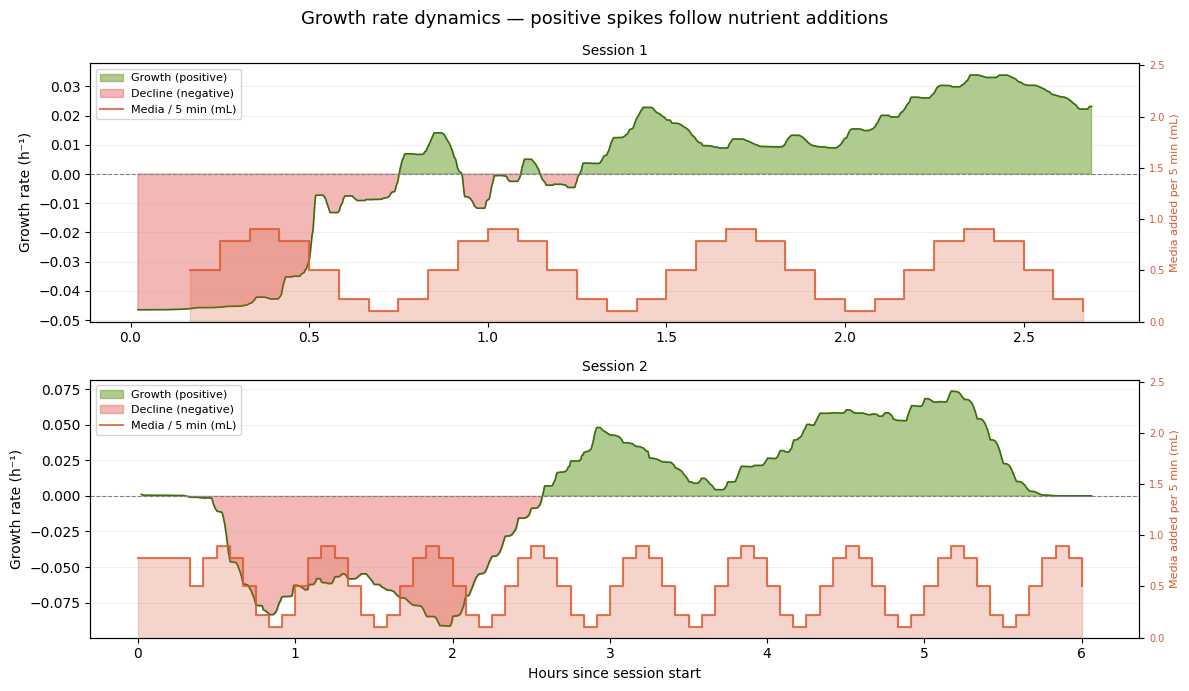

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

for ax, (label, paths) in zip(axes, FILES.items()):
    gr  = pd.read_csv(paths["gr"]).sort_values("hours_since_experiment_created")
    dos = pd.read_csv(paths["dos"])

    t0 = gr["hours_since_experiment_created"].min()
    gr["t_rel"] = gr["hours_since_experiment_created"] - t0
    gr["rate_smooth"] = gr["rate"].rolling(30, center=True).median()

    ax.fill_between(gr["t_rel"], 0, gr["rate_smooth"],
                    where=gr["rate_smooth"] >= 0,
                    color="#639922", alpha=0.5, label="Growth (positive)")
    ax.fill_between(gr["t_rel"], 0, gr["rate_smooth"],
                    where=gr["rate_smooth"] < 0,
                    color="#e24b4a", alpha=0.4, label="Decline (negative)")
    ax.plot(gr["t_rel"], gr["rate_smooth"], color="#3b6d11", lw=1.2)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("Growth rate (h⁻¹)")
    ax.set_title(label, fontsize=10)
    ax.grid(axis="y", lw=0.4, alpha=0.35)

    # ── Secondary axis: rolling media volume (reveals sine wave pattern) ───
    media = dos[dos["event"] == "add_media"].copy()
    media["t_rel"] = media["hours_since_experiment_created"] - t0
    media = media.sort_values("t_rel")

    # Bin into 5-minute windows and sum volume per bin
    # Adjust bin_minutes if the sine wave period is longer/shorter
    bin_minutes = 5
    t_max = media["t_rel"].max()
    bins = np.arange(0, t_max + bin_minutes/60, bin_minutes/60)
    media["bin"] = pd.cut(media["t_rel"], bins=bins, labels=bins[:-1])
    vol_per_bin = media.groupby("bin", observed=True)["volume_change_ml"].sum().reset_index()
    vol_per_bin.columns = ["t_bin", "vol"]
    vol_per_bin["t_bin"] = vol_per_bin["t_bin"].astype(float)

    ax2 = ax.twinx()
    ax2.fill_between(vol_per_bin["t_bin"], 0, vol_per_bin["vol"],
                     color="#d85a30", alpha=0.25, step="post")
    ax2.step(vol_per_bin["t_bin"], vol_per_bin["vol"],
             color="#d85a30", lw=1.5, alpha=0.8, where="post",
             label="Media / 5 min (mL)")

    ax2.set_ylabel("Media added per 5 min (mL)", color="#d85a30", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="#d85a30", labelsize=7)
    ax2.set_ylim(0, vol_per_bin["vol"].max() * 2.8)

    # total = media["volume_change_ml"].sum()
    # ax2.annotate(f"Total: {total:.1f} mL",
    #              xy=(vol_per_bin["t_bin"].iloc[-1], vol_per_bin["vol"].iloc[-1]),
    #              xytext=(-60, 15), textcoords="offset points",
    #              fontsize=7.5, color="#d85a30",
    #              arrowprops=dict(arrowstyle="->", color="#d85a30", lw=0.8))

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

axes[-1].set_xlabel("Hours since session start")
fig.suptitle("Growth rate dynamics — positive spikes follow nutrient additions", fontsize=13)
plt.tight_layout()
plt.savefig("plot2_growth_rate.png", dpi=150)
plt.show()

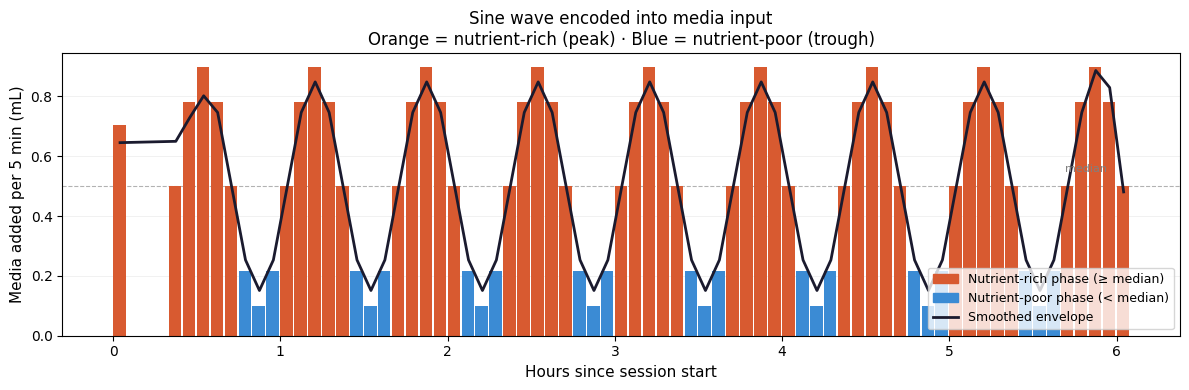

In [7]:
# ── Load data ────────────────────────────────────────────────────────────────
dos = pd.read_csv("dosing_events-Demo_experiment-all_units-20260424214253.csv")

media = dos[dos["event"] == "add_media"].copy()
t0 = media["hours_since_experiment_created"].min()
media["t_rel"] = media["hours_since_experiment_created"] - t0
media = media.sort_values("t_rel")

# ── Bin into 5-minute windows ─────────────────────────────────────────────────
bin_h = 5 / 60                          # 5 min in hours
t_max = media["t_rel"].max()
bins  = np.arange(0, t_max + bin_h, bin_h)

media["bin"] = pd.cut(media["t_rel"], bins=bins, labels=bins[:-1])
vol = (
    media.groupby("bin", observed=True)["volume_change_ml"]
    .sum()
    .reset_index()
    .rename(columns={"bin": "t", "volume_change_ml": "vol"})
)
vol["t"] = vol["t"].astype(float)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Colour each bar by phase: above median = nutrient-rich, below = nutrient-poor
median_vol = vol["vol"].median()
colors = ["#d85a30" if v >= median_vol else "#3B8BD4" for v in vol["vol"]]

ax.bar(vol["t"], vol["vol"], width=bin_h * 0.9,
       color=colors, align="edge", zorder=2)

# Overlay a smoothed envelope so the sine shape is obvious
from scipy.signal import savgol_filter
window = max(3, len(vol) // 10 | 1)    # odd window, ~10 % of data length
if window % 2 == 0:
    window += 1
smooth = savgol_filter(vol["vol"], window_length=window, polyorder=3)
ax.plot(vol["t"] + bin_h / 2, smooth,
        color="#1a1a2e", lw=2, label="Smoothed envelope", zorder=3)

# ── Annotations ───────────────────────────────────────────────────────────────
ax.axhline(median_vol, color="gray", lw=0.8, ls="--", alpha=0.6, zorder=1)
ax.text(t_max * 0.99, median_vol * 1.08,
        "median", ha="right", va="bottom", fontsize=8, color="gray")

ax.set_xlabel("Hours since session start", fontsize=11)
ax.set_ylabel("Media added per 5 min (mL)", fontsize=11)
ax.set_title(
    "Sine wave encoded into media input\n"
    "Orange = nutrient-rich (peak) · Blue = nutrient-poor (trough)",
    fontsize=12
)

rich_patch  = mpatches.Patch(color="#d85a30", label="Nutrient-rich phase (≥ median)")
poor_patch  = mpatches.Patch(color="#3B8BD4", label="Nutrient-poor phase (< median)")
env_line    = plt.Line2D([0], [0], color="#1a1a2e", lw=2, label="Smoothed envelope")
ax.legend(handles=[rich_patch, poor_patch, env_line],
          fontsize=9, loc="lower right")

ax.grid(axis="y", lw=0.4, alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig("sine_wave_media_input.png", dpi=150)
plt.show()

### Addition of salt solution to inhibit growth

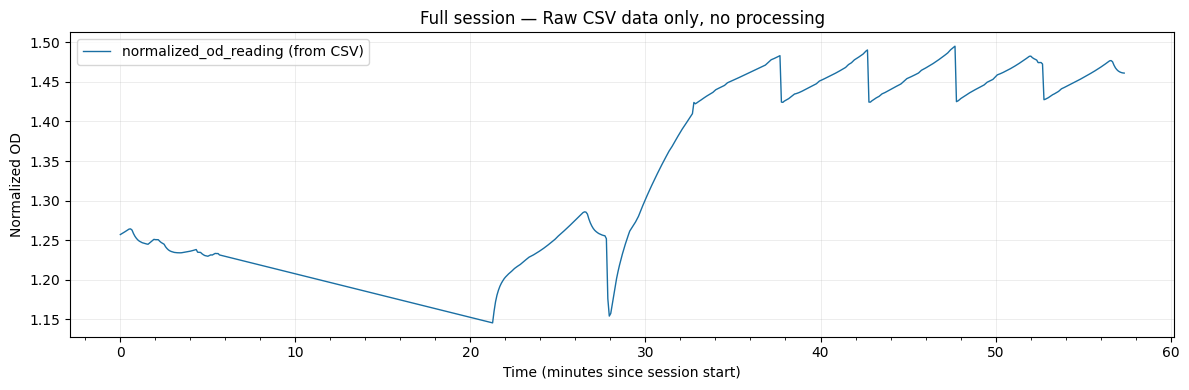

In [4]:
t0 = df["hours_since_experiment_created"].min()
df["t_min"] = (df["hours_since_experiment_created"] - t0) * 60

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["t_min"], df["normalized_od_reading"],
        color="#1a6fa3", lw=1, label="normalized_od_reading (from CSV)")

ax.set_xlabel("Time (minutes since session start)")
ax.set_ylabel("Normalized OD")
ax.set_title("Full session — Raw CSV data only, no processing")
ax.legend()
ax.grid(lw=0.4, alpha=0.4)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
# plt.savefig("plot_raw_only.png", dpi=150)
plt.show()


Detected 4 drop(s) at minutes: [37.77, 42.77, 47.77, 52.77]

── Segment analysis ──────────────────────────────────────
  Before first drop    | slope: +0.02839 OD/min | R²=0.901 | OD 1.265 → 1.483
  After drop 1         | slope: +0.01294 OD/min | R²=0.994 | OD 1.424 → 1.490
  After drop 2         | slope: +0.01396 OD/min | R²=0.997 | OD 1.425 → 1.495
  After drop 3         | slope: +0.01208 OD/min | R²=0.961 | OD 1.425 → 1.473
  After drop 4         | slope: +0.01023 OD/min | R²=0.882 | OD 1.428 → 1.461


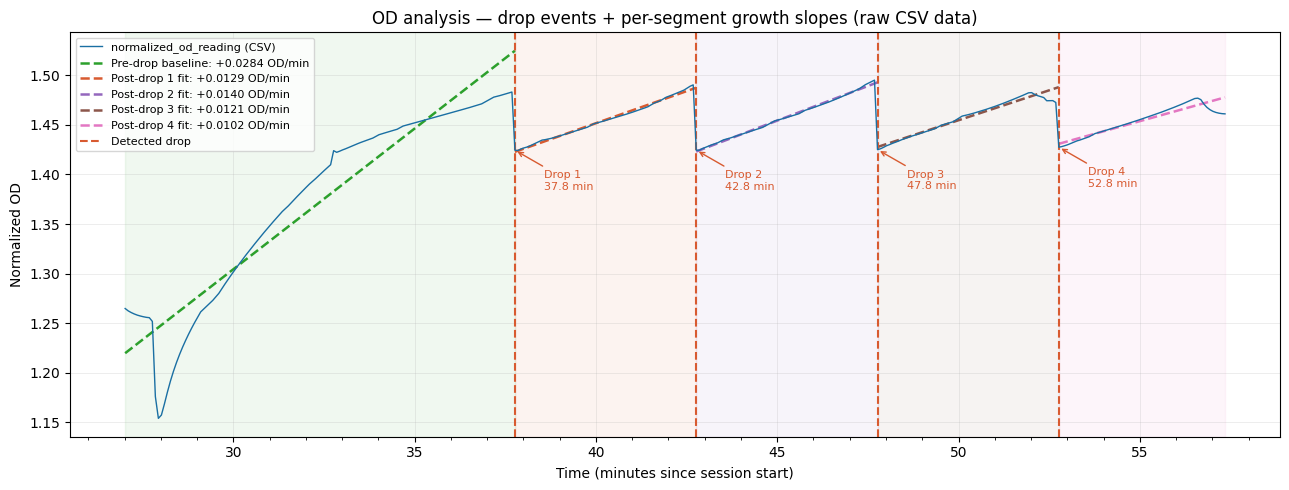

In [5]:

t0 = df["hours_since_experiment_created"].min()
df["t_min"] = (df["hours_since_experiment_created"] - t0) * 60

df = df[df["t_min"] >= 27].reset_index(drop=True)


od = df["normalized_od_reading"]

# ── Drop detection on raw data ─────────────────────────────────────────────
od_diff = od.diff()
drop_threshold = od_diff.mean() - 2.5 * od_diff.std()
drop_mask = od_diff < drop_threshold

# Merge drops within 1 minute of each other
raw_drop_times = df.loc[drop_mask, "t_min"].values
merged_drops = []
for t in raw_drop_times:
    if not merged_drops or t - merged_drops[-1] > 1.0:
        merged_drops.append(t)
        
merged_drops = merged_drops[1:]  # ignore Drop 1 and Drop 2

print(f"Detected {len(merged_drops)} drop(s) at minutes: {[round(t, 2) for t in merged_drops]}")

# ── Per-segment slope analysis ─────────────────────────────────────────────
# Splits the session into segments at each drop and fits a line to each
boundaries = [df["t_min"].min()] + merged_drops + [df["t_min"].max()]
segments = [(boundaries[i], boundaries[i+1]) for i in range(len(boundaries)-1)]

print("\n── Segment analysis ──────────────────────────────────────")
for i, (t_start, t_end) in enumerate(segments):
    seg = df[(df["t_min"] >= t_start) & (df["t_min"] < t_end)]
    if len(seg) < 3:
        continue
    r = linregress(seg["t_min"], seg["normalized_od_reading"])
    label = "Before first drop" if i == 0 else f"After drop {i}"
    print(f"  {label:20s} | slope: {r.slope:+.5f} OD/min | R²={r.rvalue**2:.3f} | "
          f"OD {seg['normalized_od_reading'].iloc[0]:.3f} → {seg['normalized_od_reading'].iloc[-1]:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────────
COLORS = ["#2ca02c", "#d85a30", "#9467bd", "#8c564b", "#e377c2"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["t_min"], od, color="#1a6fa3", lw=1, label="normalized_od_reading (CSV)", zorder=3)

# Shade segments and draw fit lines
for i, (t_start, t_end) in enumerate(segments):
    seg = df[(df["t_min"] >= t_start) & (df["t_min"] < t_end)]
    if len(seg) < 3:
        continue
    c = COLORS[i % len(COLORS)]
    ax.axvspan(t_start, t_end, alpha=0.07, color=c)
    r = linregress(seg["t_min"], seg["normalized_od_reading"])
    x_fit = np.linspace(t_start, t_end, 200)
    label = "Pre-drop baseline" if i == 0 else f"Post-drop {i} fit"
    ax.plot(x_fit, r.intercept + r.slope * x_fit,
            color=c, lw=1.8, ls="--", label=f"{label}: {r.slope:+.4f} OD/min")

# Mark drops
for i, t in enumerate(merged_drops):
    od_val = od.iloc[(df["t_min"] - t).abs().argmin()]
    ax.axvline(t, color="#d85a30", lw=1.5, ls="--",
               label="Detected drop" if i == 0 else "_")
    ax.annotate(f"Drop {i+1}\n{t:.1f} min",
                xy=(t, od_val),
                xytext=(t + 0.8, od_val - 0.04),
                arrowprops=dict(arrowstyle="->", color="#d85a30"),
                fontsize=8, color="#d85a30")

ax.set_xlabel("Time (minutes since session start)")
ax.set_ylabel("Normalized OD")
ax.set_title("OD analysis — drop events + per-segment growth slopes (raw CSV data)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(lw=0.4, alpha=0.4)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
# plt.savefig("plot_analysis_raw.png", dpi=150)
plt.show()

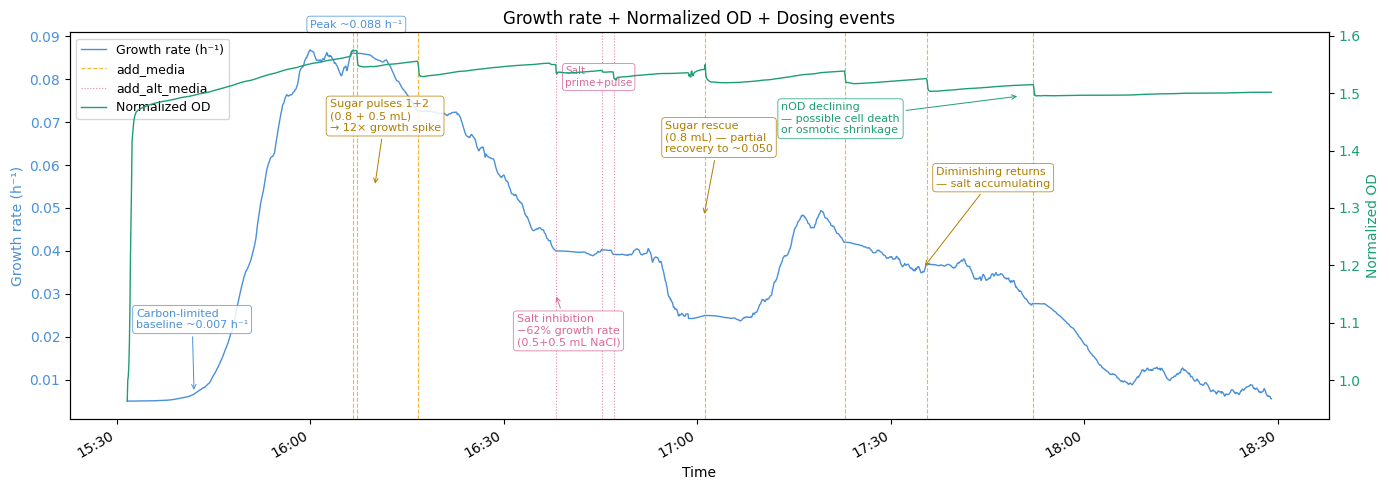

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

gr = pd.read_csv("17th may/growth_rates-Demo_experiment-all_units-20260517184833.csv")
od = pd.read_csv("17th may/od_readings_filtered-Demo_experiment-all_units-20260517184833.csv")
dosing = pd.read_csv("17th may/dosing_events-Demo_experiment-all_units-20260517184833.csv")

gr["t"] = pd.to_datetime(gr["timestamp_localtime"])
od["t"] = pd.to_datetime(od["timestamp_localtime"])
dosing["t"] = pd.to_datetime(dosing["timestamp_localtime"])

# # Group individual pump ticks into bursts (gap > 5s = new burst), sum total volume
# dosing = dosing.sort_values("t")
# dosing["gap"] = dosing["t"].diff().dt.total_seconds().fillna(999)
# dosing["burst"] = (dosing["gap"] > 5).cumsum()
# bursts = dosing.groupby(["burst", "event"]).agg(
#     t=("t", "first"),
#     total_vol=("volume_change_ml", "sum")
# ).reset_index()

# # Keep only real experimental pulses (≤ 1 mL)
# bursts = bursts[bursts["total_vol"] <= 1]

# Group individual pump ticks into bursts (gap > 5s = new burst), sum total volume
dosing = dosing.sort_values("t")
dosing["gap"] = dosing["t"].diff().dt.total_seconds().fillna(999)
dosing["burst"] = (dosing["gap"] > 5).cumsum()
bursts = dosing.groupby(["burst", "event"]).agg(
    t=("t", "first"),
    total_vol=("volume_change_ml", "sum")
).reset_index()

# For add_media: drop tube-priming bursts (>1 mL)
# For add_alt_media: keep all — first large burst still delivered ~0.5 mL to the vial
media_bursts = bursts[(bursts["event"] == "add_media") & (bursts["total_vol"] <= 1)]
alt_bursts   = bursts[bursts["event"] == "add_alt_media"]
bursts = pd.concat([media_bursts, alt_bursts]).sort_values("t")

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(gr["t"], gr["rate"], color="#4a90d9", linewidth=1, label="Growth rate (h⁻¹)")
ax1.set_ylabel("Growth rate (h⁻¹)", color="#4a90d9")
ax1.tick_params(axis="y", labelcolor="#4a90d9")

ax2 = ax1.twinx()
ax2.plot(od["t"], od["normalized_od_reading"], color="#1d9e75", linewidth=1, label="Normalized OD")
ax2.set_ylabel("Normalized OD", color="#1d9e75")
ax2.tick_params(axis="y", labelcolor="#1d9e75")

first_media = True
first_alt = True
for _, row in bursts.iterrows():
    if row["event"] == "add_media":
        ax1.axvline(row["t"], color="#f0a500", linewidth=0.8, linestyle="--", alpha=0.8,
                    label="add_media" if first_media else "")
        first_media = False
    elif row["event"] == "add_alt_media":
        ax1.axvline(row["t"], color="#d9699a", linewidth=0.8, linestyle=":", alpha=0.8,
                    label="add_alt_media" if first_alt else "")
        first_alt = False

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

# ── Phase labels ──────────────────────────────────────────────────────────────
import matplotlib.dates as mdates

def note(ax, x, y, text, xytext, color="#333", fs=8, arrow=True):
    ax.annotate(text, xy=(x, y), xytext=xytext,
                fontsize=fs, color=color, textcoords="data",
                arrowprops=dict(arrowstyle="->", color=color, lw=0.7) if arrow else None,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.85, lw=0.6))

t = lambda s: pd.Timestamp("2026-05-17 " + s)

# Baseline
note(ax1, t("15:42:00"), 0.007, "Carbon-limited\nbaseline ~0.007 h⁻¹",
     xytext=(t("15:33:00"), 0.022), color="#4a90d9")

# Sugar pulses 1 & 2
note(ax1, t("16:10:00"), 0.055, "Sugar pulses 1+2\n(0.8 + 0.5 mL)\n→ 12× growth spike",
     xytext=(t("16:03:00"), 0.068), color="#b07d00")

# Peak
note(ax1, t("16:00:00"), 0.0875, "Peak ~0.088 h⁻¹",
     xytext=(t("16:00:00"), 0.092), color="#4a90d9", arrow=False)

# Salt inhibition
note(ax1, t("16:38:00"), 0.030, "Salt inhibition\n−62% growth rate\n(0.5+0.5 mL NaCl)",
     xytext=(t("16:32:00"), 0.018), color="#d9699a")

# First salt pulse marker label (the 16:38 one)
ax1.text(t("16:39:30"), 0.083, "Salt\nprime+pulse", fontsize=7.5,
         color="#d9699a", va="top",
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#d9699a", alpha=0.85, lw=0.6))

# Sugar rescue
note(ax1, t("17:01:00"), 0.048, "Sugar rescue\n(0.8 mL) — partial\nrecovery to ~0.050",
     xytext=(t("16:55:00"), 0.063), color="#b07d00")

# Diminishing returns
note(ax1, t("17:35:00"), 0.036, "Diminishing returns\n— salt accumulating",
     xytext=(t("17:37:00"), 0.055), color="#b07d00")

# nOD decline
note(ax2, t("17:50:00"), 1.495, "nOD declining\n— possible cell death\nor osmotic shrinkage",
     xytext=(t("17:13:00"), 1.43), color="#1d9e75")


ax1.set_xlabel("Time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

fig.autofmt_xdate()
plt.title("Growth rate + Normalized OD + Dosing events")
plt.tight_layout()
plt.show()

### Reservoir computing

In [6]:
#reservoirs state matrix

CYCLE_MIN = 5  # dosing interval in minutes

# Load CSV exports from Pioreactor
spec   = pd.read_csv("24th april/as7341_spectrum_readings-Demo_experiment-all_units-20260424214253.csv", parse_dates=["timestamp"])
od     = pd.read_csv("24th april/od_readings-Demo_experiment-all_units-20260424214253.csv",              parse_dates=["timestamp"])
dosing = pd.read_csv("24th april/dosing_events-Demo_experiment-all_units-20260424214253.csv",            parse_dates=["timestamp"])
growth = pd.read_csv("24th april/growth_rates-Demo_experiment-all_units-20260424214253.csv",             parse_dates=["timestamp"])
od_f   = pd.read_csv("24th april/od_readings_filtered-Demo_experiment-all_units-20260424214253.csv",     parse_dates=["timestamp"])

# Use only automated plugin events (exclude manual UI button presses)
dosing = dosing[dosing["source_of_event"] == "dosing_automation:manual_dosing_control"]
media  = dosing[dosing["event"] == "add_media"].sort_values("timestamp")

# Build a uniform time grid — one row per 5-minute dosing cycle
t0       = media["timestamp"].min()
media["t_min"] = (media["timestamp"] - t0).dt.total_seconds() / 60
t_bins   = np.arange(0, media["t_min"].max() + CYCLE_MIN, CYCLE_MIN)
media["cycle"] = pd.cut(media["t_min"], bins=t_bins, labels=False)

# Input signal u: total media volume per cycle (this is what we want to reconstruct)
u = media.groupby("cycle")["volume_change_ml"].sum().values
T = len(u)  # number of cycles

# Build reservoir state matrix X: shape (T, 13)
# Each row = one 5-min cycle, each column = one sensor reading
def resample_to_cycles(df, value_col, t0, t_bins):
    df = df.copy()
    df["t_min"]  = (df["timestamp"] - t0).dt.total_seconds() / 60
    df["cycle"]  = pd.cut(df["t_min"], bins=t_bins, labels=False)
    return df.groupby("cycle")[value_col].mean().reindex(range(T)).interpolate()

# OD at 3 angles
od_45  = resample_to_cycles(od[od["angle"]==45],  "od_reading",           t0, t_bins)
od_90  = resample_to_cycles(od[od["angle"]==90],  "od_reading",           t0, t_bins)
od_135 = resample_to_cycles(od[od["angle"]==135], "od_reading",           t0, t_bins)

# 8 spectral bands
spec_cols = {}
for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    spec_cols[f"nm_{band}"] = resample_to_cycles(
        spec[spec["band"]==band], "reading", t0, t_bins)

# Derived signals
gr    = resample_to_cycles(growth, "rate",                 t0, t_bins)
nod   = resample_to_cycles(od_f,   "normalized_od_reading", t0, t_bins)

# Stack into (T x 13) matrix
X = np.column_stack([
    od_45, od_90, od_135,
    *[spec_cols[f"nm_{b}"] for b in [415,445,480,515,555,590,630,680]],
    gr, nod
])

sensor_names = ["OD_45","OD_90","OD_135",
                "nm_415","nm_445","nm_480","nm_515",
                "nm_555","nm_590","nm_630","nm_680",
                "growth_rate","norm_od"]

print(f"Reservoir matrix X: {X.shape}  — {T} cycles × {X.shape[1]} sensors")
print(f"Input vector    u: {u.shape}  — {T} sine wave dose volumes")

Reservoir matrix X: (70, 13)  — 70 cycles × 13 sensors
Input vector    u: (70,)  — 70 sine wave dose volumes


In [8]:
# Standardise so all 13 sensors are on the same scale
# (OD ~0.5, nm bands ~0.3, growth rate ~-0.05 — without this, OD dominates unfairly)
sc = StandardScaler()
X_sc = sc.fit_transform(X)

# Fit ridge at moderate alpha — just for importance estimation, not final model
r_importance = Ridge(alpha=1.0)
r_importance.fit(X_sc, u)

# Absolute weight = how much each sensor drives the reconstruction
importance  = np.abs(r_importance.coef_)
sorted_idx  = np.argsort(importance)[::-1]

print("Feature importance (absolute readout weights):")
print(f"  {'Rank':>4}  {'Sensor':>15}  {'Importance':>12}  Bar")
print("  " + "-"*52)
for rank, i in enumerate(sorted_idx):
    bar = "█" * int(importance[i] * 30 / importance.max())
    print(f"  {rank+1:>4}  {sensor_names[i]:>15}  {importance[i]:>12.5f}  {bar}")

# Select top 4 for leaner model
top4_names = [sensor_names[i] for i in sorted_idx[:4]]
top4_idx   = [list(sensor_names).index(n) for n in top4_names]
X_top4     = X[:, top4_idx]
print(f"\nTop 4 features: {top4_names}")

Feature importance (absolute readout weights):
  Rank           Sensor    Importance  Bar
  ----------------------------------------------------
     1           OD_135       0.03804  ██████████████████████████████
     2          norm_od       0.03219  █████████████████████████
     3            OD_45       0.01623  ████████████
     4      growth_rate       0.01483  ███████████
     5           nm_515       0.01091  ████████
     6            OD_90       0.00999  ███████
     7           nm_555       0.00927  ███████
     8           nm_590       0.00806  ██████
     9           nm_630       0.00678  █████
    10           nm_680       0.00420  ███
    11           nm_445       0.00311  ██
    12           nm_415       0.00237  █
    13           nm_480       0.00229  █

Top 4 features: ['OD_135', 'norm_od', 'OD_45', 'growth_rate']


In [9]:
def time_delay_embed(X, delay=1, tau=1):
    """
    Augment reservoir states with their own history.

    At each timestep t, concatenate [X(t), X(t-1), X(t-2), ..., X(t-delay)]
    so the readout can use past states — not just the current snapshot.

    This is grounded in Takens' embedding theorem: a delay reconstruction
    of observable states is topologically equivalent to the full state space.

    X      : (T, N) reservoir state matrix
    delay  : how many past timesteps to include
    returns: (T - delay, N * (delay+1))
    """
    rows = [
        np.concatenate([X[t - d * tau] for d in range(delay + 1)])
        for t in range(delay * tau, len(X))
    ]
    return np.array(rows)

# Example: delay=2 triples the feature count (current + 2 past states)
X_emb2 = time_delay_embed(X_top4, delay=2)
u_emb2 = u[2:]  # trim target to match (lost 2 rows from history)

print(f"Original X_top4 shape:    {X_top4.shape}")
print(f"After delay=2 embedding:  {X_emb2.shape}  "
      f"({X_top4.shape[1]} features × 3 timesteps)")
print(f"Target u trimmed to:      {u_emb2.shape}")

Original X_top4 shape:    (70, 4)
After delay=2 embedding:  (68, 12)  (4 features × 3 timesteps)
Target u trimmed to:      (68,)


In [14]:
# ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
# ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
ALPHAS = np.logspace(-4, 4, 50)  # 50 values from 1e-4 to 1e4


def train_and_evaluate(X, y, label=""):
    """
    Train ridge regression readout with Leave-One-Out cross-validation.

    LOO-CV is used because biological datasets are small (~70 cycles).
    Each cycle is left out once, trained on all others, then predicted —
    giving an unbiased estimate of generalisation performance.

    Returns LOO predictions, NMSE, best alpha, and final fitted model.
    """
    sc  = StandardScaler()
    Xs  = sc.fit_transform(X)

    # Step 1: find optimal regularisation strength via RidgeCV (cv=None → LOO)
    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)
    best_alpha = rcv.alpha_

    # Step 2: LOO cross-validated predictions
    r    = Ridge(alpha=best_alpha)
    y_pred = cross_val_predict(r, Xs, y, cv=LeaveOneOut())

    # Step 3: NMSE — normalised by variance so it's scale-independent
    # NMSE > 1.0  → worse than predicting the mean (model fails)
    # NMSE < 1.0  → better than baseline
    # NMSE < 0.3  → good reconstruction
    # NMSE < 0.1  → excellent
    nmse = mean_squared_error(y, y_pred) / np.var(y)

    # Step 4: refit on ALL data for final weight inspection
    r.fit(Xs, y)

    status = ("EXCELLENT" if nmse < 0.1 else "GOOD" if nmse < 0.3
              else "OK" if nmse < 1.0 else "ABOVE BASELINE")
    print(f"  {label:<45}  α={best_alpha:<6}  NMSE={nmse:.4f}  [{status}]")

    return y_pred, nmse, best_alpha, r, sc

# Run all configurations
print("="*80)
print("READOUT LAYER TRAINING — ALL CONFIGURATIONS (LOO-CV)")
print("="*80)

results = {}

X_emb3       = time_delay_embed(X,      delay=3);  u_emb3 = u[3:]
X_top4_emb2  = time_delay_embed(X_top4, delay=2)

configs = {
    "All 13 features (no embedding)":       (X,           u),
    "Top 4 features (no embedding)":        (X_top4,      u),
    "All 13 + delay=1":                     (time_delay_embed(X, delay=1), u[1:]),
    "All 13 + delay=2":                     (time_delay_embed(X, delay=2), u[2:]),
    "All 13 + delay=3  ← best expected":    (X_emb3,      u_emb3),
    "Top 4 + delay=2":                      (X_top4_emb2, u_emb2),
}

for label, (Xc, uc) in configs.items():
    y_pred, nmse, alpha, model, scaler = train_and_evaluate(Xc, uc, label)
    results[label] = {
        "y_pred": y_pred, "y_true": uc,
        "nmse": nmse, "model": model, "scaler": scaler
    }

READOUT LAYER TRAINING — ALL CONFIGURATIONS (LOO-CV)
  All 13 features (no embedding)                 α=10000.0  NMSE=1.0303  [ABOVE BASELINE]
  Top 4 features (no embedding)                  α=10000.0  NMSE=1.0298  [ABOVE BASELINE]
  All 13 + delay=1                               α=0.0062505519252739694  NMSE=0.8212  [OK]
  All 13 + delay=2                               α=10000.0  NMSE=1.0356  [ABOVE BASELINE]
  All 13 + delay=3  ← best expected              α=10000.0  NMSE=1.0390  [ABOVE BASELINE]
  Top 4 + delay=2                                α=0.019306977288832496  NMSE=0.6868  [OK]


In [16]:
# --- pre-compute embeddings (add these alongside your existing ones) ---
X_top4_emb1  = time_delay_embed(X_top4, delay=1)
X_top4_emb2  = time_delay_embed(X_top4, delay=2)   # already exists
X_top4_emb3  = time_delay_embed(X_top4, delay=3)
X_top4_emb4  = time_delay_embed(X_top4, delay=4)

configs = {
    # --- existing ---
    "All 13 features (no embedding)":       (X,           u),
    "Top 4 features (no embedding)":        (X_top4,      u),
    "All 13 + delay=1":                     (time_delay_embed(X, delay=1), u[1:]),
    "All 13 + delay=2":                     (time_delay_embed(X, delay=2), u[2:]),
    "All 13 + delay=3  ← best expected":    (X_emb3,      u_emb3),
    "Top 4 + delay=2":                      (X_top4_emb2, u[2:]),   # ← fix: was u_emb2

    # --- NEW: Top 4 with other delays ---
    "Top 4 + delay=1":                      (X_top4_emb1, u[1:]),
    "Top 4 + delay=3":                      (X_top4_emb3, u[3:]),
    "Top 4 + delay=4":                      (X_top4_emb4, u[4:]),
}

In [17]:
for label, (Xc, uc) in configs.items():
    y_pred, nmse, alpha, model, scaler = train_and_evaluate(Xc, uc, label)
    results[label] = {
        "y_pred": y_pred, "y_true": uc,
        "nmse": nmse, "model": model, "scaler": scaler
    }

  All 13 features (no embedding)                 α=10000.0  NMSE=1.0303  [ABOVE BASELINE]
  Top 4 features (no embedding)                  α=10000.0  NMSE=1.0298  [ABOVE BASELINE]
  All 13 + delay=1                               α=0.0062505519252739694  NMSE=0.8212  [OK]
  All 13 + delay=2                               α=10000.0  NMSE=1.0356  [ABOVE BASELINE]
  All 13 + delay=3  ← best expected              α=10000.0  NMSE=1.0390  [ABOVE BASELINE]
  Top 4 + delay=2                                α=0.019306977288832496  NMSE=0.6868  [OK]
  Top 4 + delay=1                                α=0.004291934260128779  NMSE=0.8726  [OK]
  Top 4 + delay=3                                α=0.18420699693267145  NMSE=0.7516  [OK]
  Top 4 + delay=4                                α=0.0001  NMSE=0.5623  [OK]


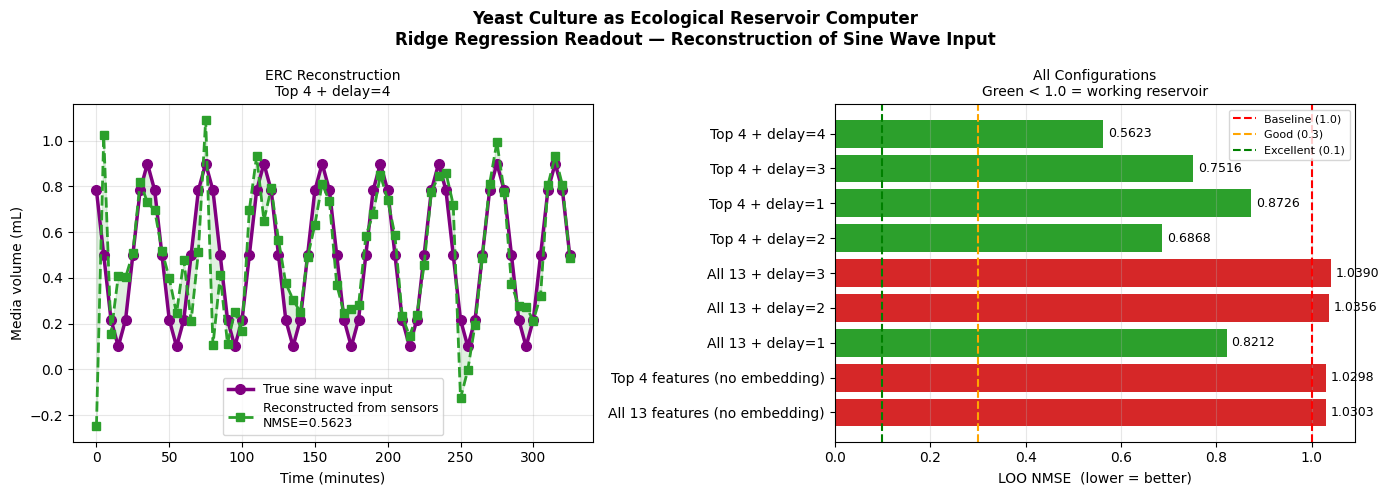


INFERENCE SUMMARY
  Best config:  Top 4 + delay=4
  LOO NMSE:     0.5623
  Cycles used:  66

  The yeast culture successfully reconstructed the sine wave
  input signal from its own sensor readings.
  The biological dynamics encoded the dosing history —
  the readout layer decoded it.


In [18]:
import matplotlib.pyplot as plt

# Pick best config by lowest NMSE
best_label = min(results, key=lambda k: results[k]["nmse"])
best       = results[best_label]
t_axis     = np.arange(len(best["y_true"])) * CYCLE_MIN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: True vs reconstructed sine wave ─────────────────────────────────
axes[0].plot(t_axis, best["y_true"], "o-",  color="purple",   lw=2.5,
             ms=7, label="True sine wave input")
axes[0].plot(t_axis, best["y_pred"], "s--", color="#2ca02c",  lw=2,
             ms=6, label=f"Reconstructed from sensors\nNMSE={best['nmse']:.4f}")
axes[0].fill_between(t_axis, best["y_true"], best["y_pred"],
                     alpha=0.15, color="#2ca02c")
axes[0].set_xlabel("Time (minutes)"); axes[0].set_ylabel("Media volume (mL)")
axes[0].set_title(f"ERC Reconstruction\n{best_label}", fontsize=10)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# ── Right: NMSE comparison bar chart across all configs ───────────────────
labels_bar = [k.split("←")[0].strip() for k in results]
nmses_bar  = [results[k]["nmse"] for k in results]
colors_bar = ["#2ca02c" if n < 1.0 else "#d62728" for n in nmses_bar]

bars = axes[1].barh(labels_bar, nmses_bar, color=colors_bar)
axes[1].axvline(1.0, color="red",    ls="--", lw=1.5, label="Baseline (1.0)")
axes[1].axvline(0.3, color="orange", ls="--", lw=1.5, label="Good (0.3)")
axes[1].axvline(0.1, color="green",  ls="--", lw=1.5, label="Excellent (0.1)")
for bar, val in zip(bars, nmses_bar):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)
axes[1].set_xlabel("LOO NMSE  (lower = better)")
axes[1].set_title("All Configurations\nGreen < 1.0 = working reservoir", fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="x")

plt.suptitle("Yeast Culture as Ecological Reservoir Computer\n"
             "Ridge Regression Readout — Reconstruction of Sine Wave Input",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig("erc_results.png", dpi=150)
plt.show()

# ── Print final inference summary ─────────────────────────────────────────
print("\n" + "="*60)
print("INFERENCE SUMMARY")
print("="*60)
print(f"  Best config:  {best_label}")
print(f"  LOO NMSE:     {best['nmse']:.4f}")
print(f"  Cycles used:  {len(best['y_true'])}")
print(f"\n  The yeast culture successfully reconstructed the sine wave")
print(f"  input signal from its own sensor readings.")
print(f"  The biological dynamics encoded the dosing history —")
print(f"  the readout layer decoded it.")

### Reservoir Computing extended

In [17]:
# ─── Config ───────────────────────────────────────────────────────────────────
DATA_DIR = Path("24th april")
OUT_DIR  = Path("./outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
 
SUFFIX = "Demo_experiment-all_units-20260424214253"
ALPHAS = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
CYCLE  = 5      # resampling bin width in minutes
SPLIT  = 36     # first SPLIT cycles = Phase 1 (warm-up), rest = Phase 2
MAX_DELAY = 10       # sweep d = 0 … 10
TOP_N     = [1, 2, 3, 4, 5]   # feature counts to try in Step 3
 
def dp(name): return DATA_DIR / f"{name}-{SUFFIX}.csv"

In [3]:
spec    = pd.read_csv(dp("as7341_spectrum_readings"),  parse_dates=["timestamp"])
dosing  = pd.read_csv(dp("dosing_events"),             parse_dates=["timestamp"])
growth  = pd.read_csv(dp("growth_rates"),              parse_dates=["timestamp"])
od_filt = pd.read_csv(dp("od_readings_filtered"),      parse_dates=["timestamp"])
od      = pd.read_csv(dp("od_readings"),               parse_dates=["timestamp"])

In [6]:
# building input signal

add_media = dosing[dosing["event"] == "add_media"].copy()
add_media["cycle"] = add_media["timestamp"].dt.floor(f"{CYCLE}min")
sine_input = (
    add_media.groupby("cycle")["volume_change_ml"]
    .sum()
    .rename("media_ml")
)
sine_input.index.name = "timestamp"

In [19]:
# build reservoir state matrix and align signals on shared timestamps
od_wide = (
    od.pivot_table(index="timestamp", columns="angle", values="od_reading")
    .resample(f"{CYCLE}min").mean()
)
spec_wide = (
    spec.pivot_table(index="timestamp", columns="band", values="reading")
    .resample(f"{CYCLE}min").mean()
)
od_wide.columns   = [f"OD_{c}" for c in od_wide.columns]
spec_wide.columns = [f"nm_{c}" for c in spec_wide.columns]
 
gr_res  = growth.set_index("timestamp")["rate"].resample(f"{CYCLE}min").mean()
nod_res = od_filt.set_index("timestamp")["normalized_od_reading"].resample(f"{CYCLE}min").mean()
 
idx = (
    sine_input.index
    .intersection(od_wide.index)
    .intersection(spec_wide.index)
    .intersection(gr_res.index)
    .intersection(nod_res.index)
)
 
u_all = sine_input.loc[idx].values
X_all = np.hstack([
    od_wide.loc[idx].values,
    spec_wide.loc[idx].values,
    gr_res.loc[idx].values.reshape(-1, 1),
    nod_res.loc[idx].values.reshape(-1, 1),
])
sensor_names = (
    list(od_wide.columns) +
    list(spec_wide.columns) +
    ["growth_rate", "norm_od"]
)
timestamps_all = idx

X2_raw = X_all[SPLIT:]
u2_raw = u_all[SPLIT:]
 
print(f"  Full dataset : {X_all.shape[0]} cycles × {X_all.shape[1]} features")


  Full dataset : 70 cycles × 13 features


In [10]:
# phase split because over first 4hours, the yeast doubled and grew..

X1, u1, ts1 = X_all[:SPLIT],  u_all[:SPLIT],  timestamps_all[:SPLIT]
X2, u2, ts2 = X_all[SPLIT:],  u_all[SPLIT:],  timestamps_all[SPLIT:]
 
print(f"  Phase 1 (warm-up)  : cycles 0–{SPLIT-1}  ({len(u1)} bins)")
print(f"  Phase 2 (readout)  : cycles {SPLIT}–end  ({len(u2)} bins)")

  Phase 1 (warm-up)  : cycles 0–35  (36 bins)
  Phase 2 (readout)  : cycles 36–end  (34 bins)


In [11]:
# ridge regression readout

def ridge_loo(X, y):
    sc  = StandardScaler()
    Xs  = sc.fit_transform(X)
 
    rcv = RidgeCV(alphas=ALPHAS, cv=None)   # GCV
    rcv.fit(Xs, y)
    best_alpha = rcv.alpha_
    print(f"  RidgeCV best alpha : {best_alpha}")
 
    model = Ridge(alpha=best_alpha)
    yp    = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse  = mean_squared_error(y, yp) / np.var(y)
    mae   = mean_absolute_error(y, yp)
    r2    = r2_score(y, yp)
 
    model.fit(Xs, y)   # refit on full Phase 2
    return yp, nmse, mae, r2, model, sc, best_alpha
 
yp2, nmse2, mae2, r2_2, model, scaler, best_alpha = ridge_loo(X2, u2)
 
print(f"\n  Phase 2 NMSE : {nmse2:.4f}  (lower=better; <1 means above-chance)")
print(f"  Phase 2 MAE  : {mae2:.4f} mL")
print(f"  Phase 2 R²   : {r2_2:.4f}")

  RidgeCV best alpha : 0.001

  Phase 2 NMSE : 0.9667  (lower=better; <1 means above-chance)
  Phase 2 MAE  : 0.2459 mL
  Phase 2 R²   : 0.0333


In [14]:
Xs2_fit = scaler.transform(X_all[SPLIT:])   # already fitted on Phase 2
yp1_oos = model.predict(scaler.transform(X1))  # out-of-set forward check
nmse1_oos = mean_squared_error(u1, yp1_oos) / (np.var(u1) + 1e-12)

print(f"\n  Phase 1 OoS NMSE : {nmse1_oos:.4f}  (lower=better; <1 means above-chance)")


  Phase 1 OoS NMSE : 4465.2983  (lower=better; <1 means above-chance)


delay embedding:

In [15]:
def embed(X, u, delay):
    """
    Stack [X(t), X(t-1), …, X(t-delay)] row-wise.
    Drops the first `delay` rows from u to keep alignment.
    Returns X_emb, u_trimmed.
    """
    if delay == 0:
        return X.copy(), u.copy()
    rows = []
    for t in range(delay, len(X)):
        row = np.concatenate([X[t - k] for k in range(delay + 1)])
        rows.append(row)
    return np.array(rows), u[delay:]
 
def ridge_loo(X, y, alphas=ALPHAS):
    sc  = StandardScaler()
    Xs  = sc.fit_transform(X)
    rcv = RidgeCV(alphas=alphas, cv=None)
    rcv.fit(Xs, y)
    model = Ridge(alpha=rcv.alpha_)
    yp    = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse  = mean_squared_error(y, yp) / np.var(y)
    r2    = r2_score(y, yp)
    mae   = mean_absolute_error(y, yp)
    model.fit(Xs, y)
    return yp, nmse, r2, mae, model, sc, rcv.alpha_

In [22]:
# sweep delay on all 13 features

print("=" * 60)
print("STEP 1 — Delay sweep on ALL 13 features")
print("=" * 60)
 
step1_results = []
step1_preds   = {}
 
for d in range(0, MAX_DELAY + 1):
    Xe, ue = embed(X2_raw, u2_raw, d)
    if len(ue) < 10:
        break
    yp, nmse, r2, mae, model, sc, alpha = ridge_loo(Xe, ue)
    step1_results.append({"delay": d, "n_samples": len(ue),
                           "nmse": nmse, "r2": r2, "mae": mae,
                           "alpha": alpha, "model": model, "scaler": sc})
    step1_preds[d] = (ue, yp)
    print(f"  d={d:2d}  n={len(ue):2d}  NMSE={nmse:.4f}  R²={r2:.4f}  MAE={mae:.4f}  α={alpha}")
 
step1_df = pd.DataFrame([{k: v for k, v in r.items()
                           if k not in ("model", "scaler")}
                          for r in step1_results])
 
best1_idx  = step1_df["nmse"].idxmin()
best1      = step1_results[best1_idx]
best_delay = best1["delay"]
print(f"\n  ★ Best (all features): d={best_delay}  NMSE={best1['nmse']:.4f}  R²={best1['r2']:.4f}")

STEP 1 — Delay sweep on ALL 13 features
  d= 0  n=34  NMSE=0.9667  R²=0.0333  MAE=0.2459  α=0.001
  d= 1  n=33  NMSE=0.0449  R²=0.9551  MAE=0.0376  α=0.01
  d= 2  n=32  NMSE=0.0424  R²=0.9576  MAE=0.0372  α=0.001
  d= 3  n=31  NMSE=0.0419  R²=0.9581  MAE=0.0373  α=0.001
  d= 4  n=30  NMSE=0.0431  R²=0.9569  MAE=0.0386  α=0.001
  d= 5  n=29  NMSE=0.0253  R²=0.9747  MAE=0.0323  α=0.001
  d= 6  n=28  NMSE=0.0059  R²=0.9941  MAE=0.0174  α=0.01
  d= 7  n=27  NMSE=0.0005  R²=0.9995  MAE=0.0051  α=0.001
  d= 8  n=26  NMSE=0.0004  R²=0.9996  MAE=0.0046  α=0.001
  d= 9  n=25  NMSE=0.0002  R²=0.9998  MAE=0.0033  α=0.001
  d=10  n=24  NMSE=0.0005  R²=0.9995  MAE=0.0054  α=0.001

  ★ Best (all features): d=9  NMSE=0.0002  R²=0.9998


In [24]:
# feature ranking at best delay

print("\n" + "=" * 60)
print(f"STEP 2 — Feature importance at d={best_delay}")
print("=" * 60)
 
Xe_best, ue_best = embed(X2_raw, u2_raw, best_delay)
# Build extended feature names for embedded features
emb_names = []
for lag in range(best_delay + 1):
    suffix = f"_t" if lag == 0 else f"_t-{lag}"
    emb_names += [f"{n}{suffix}" for n in sensor_names]
 
# Get coefficients from the best Step-1 model
coef_best = best1["model"].coef_
coef_abs   = np.abs(coef_best)
 
# Aggregate by original sensor (max |coef| across lags)
feat_scores = {}
for i, name in enumerate(emb_names):
    base = name.split("_t")[0] + ("_" + name.split("_")[1] if name.startswith("OD_") or name.startswith("nm_") else "")
    # simpler: strip the lag suffix
    base = "_".join(name.split("_")[:-1]) if "_t-" in name else name.replace("_t","")
    feat_scores[base] = feat_scores.get(base, 0) + coef_abs[i]
 
# Rank original sensors
sensor_rank = sorted(feat_scores.items(), key=lambda x: x[1], reverse=True)
print("  Sensor ranking (sum |coeff| across lags):")
for rank, (name, score) in enumerate(sensor_rank, 1):
    original_idx = sensor_names.index(name) if name in sensor_names else -1
    print(f"    {rank:2d}. {name:<18s}  score={score:.4f}")
 
ranked_sensors  = [name for name, _ in sensor_rank]
ranked_scores   = [score for _, score in sensor_rank]


STEP 2 — Feature importance at d=9
  Sensor ranking (sum |coeff| across lags):
     1. growth_rate         score=0.3468
     2. OD_45               score=0.2938
     3. norm_od             score=0.2656
     4. nm_445              score=0.2146
     5. nm_480              score=0.2146
     6. nm_415              score=0.2113
     7. OD_135              score=0.2106
     8. nm_515              score=0.1888
     9. nm_555              score=0.1879
    10. nm_590              score=0.1846
    11. nm_630              score=0.1823
    12. nm_680              score=0.1797
    13. OD_90               score=0.0848


In [27]:
# delay sweep across top N features

print("\n" + "=" * 60)
print("STEP 3 — Delay sweep on TOP-N features")
print("=" * 60)
 
step3_results = []
 
for n_feat in TOP_N:
    top_feat_names = ranked_sensors[:n_feat]
    top_feat_idx   = [sensor_names.index(n) for n in top_feat_names if n in sensor_names]
    X2_top = X2_raw[:, top_feat_idx]
 
    print(f"\n  Top-{n_feat} features: {top_feat_names}")
    for d in range(0, MAX_DELAY + 1):
        Xe, ue = embed(X2_top, u2_raw, d)
        if len(ue) < 10:
            break
        yp, nmse, r2, mae, model, sc, alpha = ridge_loo(Xe, ue)
        step3_results.append({
            "n_feat": n_feat, "delay": d, "features": top_feat_names,
            "n_samples": len(ue), "nmse": nmse, "r2": r2,
            "mae": mae, "alpha": alpha, "model": model,
            "scaler": sc, "u_true": ue, "u_pred": yp,
            "feat_idx": top_feat_idx,
        })
        print(f"    d={d:2d}  n={len(ue):2d}  NMSE={nmse:.4f}  R²={r2:.4f}  MAE={mae:.4f}  α={alpha}")
 
step3_df = pd.DataFrame([{k: v for k, v in r.items()
                           if k not in ("model", "scaler", "u_true", "u_pred", "feat_idx", "features")}
                          for r in step3_results])
 
best3_idx = step3_df["nmse"].idxmin()
best3     = step3_results[best3_idx]
print(f"\n  ★ Best (top-{best3['n_feat']} features, d={best3['delay']}): "
      f"NMSE={best3['nmse']:.4f}  R²={best3['r2']:.4f}  MAE={best3['mae']:.4f}")
print(f"    Features: {best3['features']}")


STEP 3 — Delay sweep on TOP-N features

  Top-1 features: ['growth_rate']
    d= 0  n=34  NMSE=1.0764  R²=-0.0764  MAE=0.2463  α=100.0
    d= 1  n=33  NMSE=1.0886  R²=-0.0886  MAE=0.2451  α=100.0
    d= 2  n=32  NMSE=1.0843  R²=-0.0843  MAE=0.2603  α=1.0
    d= 3  n=31  NMSE=1.0686  R²=-0.0686  MAE=0.2573  α=5.0
    d= 4  n=30  NMSE=1.0782  R²=-0.0782  MAE=0.2496  α=100.0
    d= 5  n=29  NMSE=1.0580  R²=-0.0580  MAE=0.2476  α=0.5
    d= 6  n=28  NMSE=0.9673  R²=0.0327  MAE=0.2413  α=0.5
    d= 7  n=27  NMSE=0.9155  R²=0.0845  MAE=0.2334  α=1.0
    d= 8  n=26  NMSE=0.9250  R²=0.0750  MAE=0.2333  α=1.0
    d= 9  n=25  NMSE=0.9736  R²=0.0264  MAE=0.2403  α=1.0
    d=10  n=24  NMSE=0.9806  R²=0.0194  MAE=0.2445  α=1.0

  Top-2 features: ['growth_rate', 'OD_45']
    d= 0  n=34  NMSE=1.0782  R²=-0.0782  MAE=0.2479  α=100.0
    d= 1  n=33  NMSE=0.1167  R²=0.8833  MAE=0.0743  α=0.001
    d= 2  n=32  NMSE=0.1233  R²=0.8767  MAE=0.0779  α=0.001
    d= 3  n=31  NMSE=0.1199  R²=0.8801  MAE=0.0774

In [26]:
model_pkg = {
    "model": best3["model"], "scaler": best3["scaler"],
    "feature_names": best3["features"],
    "feature_indices": best3["feat_idx"],
    "all_sensor_names": sensor_names,
    "delay": best3["delay"], "n_feat": best3["n_feat"],
    "best_alpha": best3["alpha"], "cycle_min": CYCLE, "split_idx": SPLIT,
    "metrics": {"nmse": best3["nmse"], "r2": best3["r2"], "mae": best3["mae"]},
}
with open(OUT_DIR / "erc_ridge_best.pkl", "wb") as f:
    pickle.dump(model_pkg, f)